# [Nian-Ya Weng ] — Individual Model Notebook
**Branch:** `student/<name>-model`

This notebook contains two architectures as required by AT3:
- **Model 1** (Phase 2): Individual architecture
- **Model 2** (Phase 3): Refined architecture based on group discussion

> **Prerequisites:** The shared `data_preparation.ipynb` must have been run at least once  
> and its outputs uploaded to the shared Google Drive folder before running this notebook.

## 0. Install dependencies

In [1]:
!pip install -q torch torchvision nltk Pillow matplotlib

## 1. Load processed data

In [2]:
from pathlib import Path

LOCAL_FOLDER    = Path.home() / 'Desktop' / 'dl-image-captioning-at3'
DRIVE_PROCESSED = LOCAL_FOLDER / 'processed'
DRIVE_IMAGES    = DRIVE_PROCESSED / 'images_224'
DRIVE_CHECKPTS  = LOCAL_FOLDER / 'checkpoints'

STUDENT_NAME = 'nian-ya'
MY_CHECKPTS  = DRIVE_CHECKPTS / STUDENT_NAME
MY_CHECKPTS.mkdir(parents=True, exist_ok=True)

# Verify artefacts exist
for p in [DRIVE_PROCESSED / 'vocab.pkl',
          DRIVE_PROCESSED / 'splits.json',
          DRIVE_PROCESSED / 'captions_clean.json']:
    status = 'OK' if p.exists() else 'MISSING'
    print(f'[{status}] {p.name}')

n_imgs = len(list(DRIVE_IMAGES.glob('*.jpg')))
print(f'[OK] images_224/ — {n_imgs:,} images')

[OK] vocab.pkl
[OK] splits.json
[OK] captions_clean.json
[OK] images_224/ — 7,750 images


In [3]:
import pickle, json, random
import numpy as np

with open(DRIVE_PROCESSED / 'vocab.pkl', 'rb') as f:
    vocab = pickle.load(f)

word2idx   = vocab['word2idx']
idx2word   = vocab['idx2word']
PAD_IDX    = vocab['PAD_IDX']
SOS_IDX    = vocab['SOS_IDX']
EOS_IDX    = vocab['EOS_IDX']
UNK_IDX    = vocab['UNK_IDX']
VOCAB_SIZE = len(word2idx)

with open(DRIVE_PROCESSED / 'splits.json') as f:
    splits = json.load(f)

with open(DRIVE_PROCESSED / 'captions_clean.json') as f:
    clean_data = json.load(f)

captions_clean = clean_data['captions']
id_to_filename = clean_data['id_to_filename']

print(f'Vocab size   : {VOCAB_SIZE:,}')
print(f'Train images : {len(splits["train"]):,}  Val: {len(splits["val"]):,}  Test: {len(splits["test"]):,}')

Vocab size   : 3,965
Train images : 6,181  Val: 772  Test: 774


## 2. Imports & device setup

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as T
from PIL import Image
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print('Device:', DEVICE)

Device: mps


## 3. Dataset & DataLoader

In [7]:
class VizWizDataset(Dataset):
    """Loads 224x224 images from Drive and tokenised captions from memory."""

    def __init__(self, image_ids, captions, id_to_filename, img_dir, word2idx, transform=None):
        self.samples = []
        for img_id in image_ids:
            img_id_str = str(img_id)
            fname = id_to_filename.get(img_id_str)
            if fname is None:
                continue
            for tokens in captions.get(img_id_str, []):
                indices = ([SOS_IDX]
                           + [word2idx.get(t, UNK_IDX) for t in tokens]
                           + [EOS_IDX])
                self.samples.append((img_dir / fname, indices))

        self.transform = transform or T.Compose([
            T.Resize((224, 224)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, caption_indices = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        return self.transform(img), torch.tensor(caption_indices, dtype=torch.long)


def collate_fn(batch):
    images, captions = zip(*batch)
    images = torch.stack(images)
    lengths = [len(c) for c in captions]
    padded = torch.zeros(len(captions), max(lengths), dtype=torch.long)
    for i, cap in enumerate(captions):
        padded[i, :len(cap)] = cap
    return images, padded, torch.tensor(lengths)

In [10]:
BATCH_SIZE = 32

train_dataset = VizWizDataset(splits['train'], captions_clean, id_to_filename, DRIVE_IMAGES, word2idx)
val_dataset   = VizWizDataset(splits['val'],   captions_clean, id_to_filename, DRIVE_IMAGES, word2idx)
test_dataset  = VizWizDataset(splits['test'],  captions_clean, id_to_filename, DRIVE_IMAGES, word2idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=0)

print(f'Train batches: {len(train_loader)}  Val: {len(val_loader)}  Test: {len(test_loader)}')

Train batches: 938  Val: 118  Test: 118


---
# Model 1 — Phase 2 (Individual Architecture)

## Architecture Rationale

**Encoder:** Pre-trained ResNet-50 (ImageNet weights). The classification head is removed and replaced with a linear projection layer that maps the 2048-d feature vector to `embed_size`. The convolutional layers are frozen during training to reduce computation and prevent overfitting, while only the projection layer is fine-tuned.

**Decoder:** Single-layer LSTM with an embedding layer and a linear output projection to vocabulary size. The image feature vector is used as the initial hidden state of the LSTM. Teacher forcing is applied during training.

**Design decisions:**
- ResNet-50 chosen for its strong feature extraction and wide adoption as a captioning baseline
- LSTM chosen over GRU for its proven performance on sequence generation tasks
- Embedding size and hidden size set to 256 for a balance between capacity and training speed on CPU/free Colab

In [11]:
class EncoderCNN(nn.Module):
    """Feature extractor using pre-trained ResNet-50."""

    def __init__(self, embed_size):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        # Remove classification head
        modules = list(resnet.children())[:-1]
        self.resnet = nn.Sequential(*modules)
        # Freeze all ResNet layers
        for param in self.resnet.parameters():
            param.requires_grad = False
        # Project 2048-d features to embed_size
        self.project = nn.Linear(resnet.fc.in_features, embed_size)
        self.bn = nn.BatchNorm1d(embed_size)

    def forward(self, images):
        with torch.no_grad():
            features = self.resnet(images)        # (batch, 2048, 1, 1)
        features = features.squeeze(-1).squeeze(-1)  # (batch, 2048)
        return self.bn(self.project(features))        # (batch, embed_size)


class DecoderRNN(nn.Module):
    """Caption generator using LSTM with teacher forcing."""

    def __init__(self, embed_size, hidden_size, vocab_size, num_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)
        self.feature_proj = nn.Linear(embed_size, hidden_size)

    def forward(self, features, captions):
        # captions: (batch, seq_len) including SOS but excluding last token
        embeddings = self.embedding(captions[:, :-1])         # (batch, seq_len-1, embed_size)
        # Use image features as initial hidden state
        h0 = self.feature_proj(features).unsqueeze(0)                          # (1, batch, hidden_size)
        c0 = torch.zeros_like(h0)
        outputs, _ = self.lstm(embeddings, (h0, c0))          # (batch, seq_len-1, hidden_size)
        return self.fc(outputs)                               # (batch, seq_len-1, vocab_size)

    def generate(self, features, max_len=20):
        inputs = torch.tensor([[SOS_IDX]], device=features.device)
        h = self.feature_proj(features).unsqueeze(0)
        c = torch.zeros_like(h)
        result = []
        for _ in range(max_len):
            emb = self.embedding(inputs)                      # (1, 1, embed_size)
            out, (h, c) = self.lstm(emb, (h, c))
            pred = self.fc(out.squeeze(1)).argmax(dim=-1)     # (1,)
            token = pred.item()
            if token == EOS_IDX:
                break
            result.append(token)
            inputs = pred.unsqueeze(0)
        return result

### Model 1 — Training

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /Users/amanda/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [01:21<00:00, 1.26MB/s]


Epoch 1/15:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 01/15 | Train Loss: 3.7271 | Val Loss: 3.3296
  ✓ Best model saved (val_loss=3.3296)


Epoch 2/15:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 02/15 | Train Loss: 3.0117 | Val Loss: 3.1517
  ✓ Best model saved (val_loss=3.1517)


...

Epoch 13/15 | Train Loss: 1.1868 | Val Loss: 3.8270


Epoch 14/15:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 14/15 | Train Loss: 1.1174 | Val Loss: 3.8997


Epoch 15/15:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 15/15 | Train Loss: 1.0549 | Val Loss: 4.0075


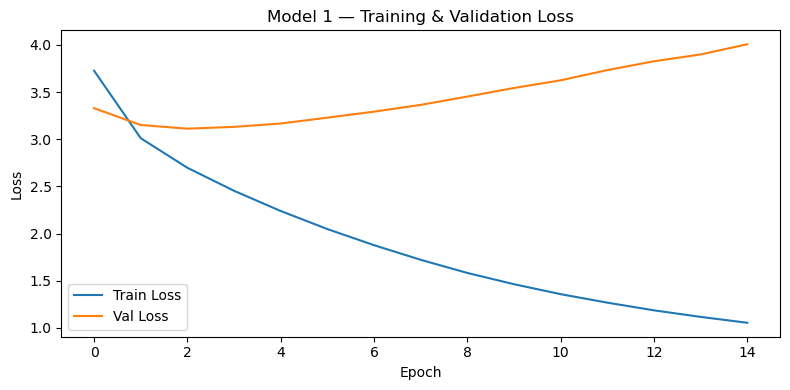

In [12]:
from tqdm.notebook import tqdm

# Hyperparameters
EMBED_SIZE  = 256
HIDDEN_SIZE = 512
NUM_LAYERS  = 1
EPOCHS      = 15
LR_DECODER  = 1e-3
LR_ENCODER  = 1e-4

encoder1 = EncoderCNN(EMBED_SIZE).to(DEVICE)
decoder1 = DecoderRNN(EMBED_SIZE, HIDDEN_SIZE, VOCAB_SIZE, NUM_LAYERS).to(DEVICE)

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = optim.Adam([
    {'params': decoder1.parameters(), 'lr': LR_DECODER},
    {'params': encoder1.project.parameters(), 'lr': LR_ENCODER},
    {'params': encoder1.bn.parameters(), 'lr': LR_ENCODER},
])

train_losses, val_losses = [], []
best_val_loss = float('inf')

for epoch in range(1, EPOCHS + 1):
    # ── Training ──────────────────────────────────────────────
    encoder1.train()
    decoder1.train()
    running_loss = 0.0

    for images, captions, lengths in tqdm(train_loader, desc=f'Epoch {epoch}/{EPOCHS}'):
        images   = images.to(DEVICE)
        captions = captions.to(DEVICE)

        features = encoder1(images)
        outputs  = decoder1(features, captions)

        targets = captions[:, 1:]
        loss = criterion(outputs.reshape(-1, VOCAB_SIZE), targets.reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(decoder1.parameters(), max_norm=5)
        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # ── Validation ────────────────────────────────────────────
    encoder1.eval()
    decoder1.eval()
    val_loss = 0.0

    with torch.no_grad():
        for images, captions, lengths in val_loader:
            images   = images.to(DEVICE)
            captions = captions.to(DEVICE)
            features = encoder1(images)
            outputs  = decoder1(features, captions)
            targets  = captions[:, 1:]
            loss = criterion(outputs.reshape(-1, VOCAB_SIZE), targets.reshape(-1))
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    print(f'Epoch {epoch:02d}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')

    # ── Save best checkpoint ───────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch': epoch,
            'encoder': encoder1.state_dict(),
            'decoder': decoder1.state_dict(),
            'optimizer': optimizer.state_dict(),
            'val_loss': val_loss,
        }, MY_CHECKPTS / 'model1_best.pth')
        print(f'  ✓ Best model saved (val_loss={val_loss:.4f})')

# ── Plot loss curves ───────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model 1 — Training & Validation Loss')
plt.legend()
plt.tight_layout()
plt.savefig(MY_CHECKPTS / 'model1_loss.png')
plt.show()

### Model 1 — Evaluation (BLEU-1 to BLEU-4)

In [13]:
import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

nltk.download('punkt', quiet=True)

# Load best checkpoint
checkpoint = torch.load(MY_CHECKPTS / 'model1_best.pth', map_location=DEVICE)
encoder1.load_state_dict(checkpoint['encoder'])
decoder1.load_state_dict(checkpoint['decoder'])
encoder1.eval()
decoder1.eval()

# Generate captions and collect references
references = []
hypotheses = []

with torch.no_grad():
    for images, captions, lengths in tqdm(test_loader, desc='Evaluating'):
        images = images.to(DEVICE)
        features = encoder1(images)

        for i in range(images.size(0)):
            # Generate caption using greedy decoding
            feat = features[i].unsqueeze(0)
            pred_indices = decoder1.generate(feat, max_len=20)
            hypothesis = [idx2word.get(idx, '<UNK>') for idx in pred_indices]
            hypotheses.append(hypothesis)

            # Extract reference caption (remove PAD, SOS, EOS tokens)
            cap = captions[i].tolist()
            ref = [idx2word.get(idx, '<UNK>') for idx in cap
                   if idx not in [PAD_IDX, SOS_IDX, EOS_IDX]]
            references.append([ref])

# Compute BLEU-1 to BLEU-4 with smoothing
smoother = SmoothingFunction().method1
bleu1 = corpus_bleu(references, hypotheses, weights=(1,0,0,0), smoothing_function=smoother)
bleu2 = corpus_bleu(references, hypotheses, weights=(0.5,0.5,0,0), smoothing_function=smoother)
bleu3 = corpus_bleu(references, hypotheses, weights=(0.33,0.33,0.33,0), smoothing_function=smoother)
bleu4 = corpus_bleu(references, hypotheses, weights=(0.25,0.25,0.25,0.25), smoothing_function=smoother)

# Print results
print(f'BLEU-1: {bleu1:.4f}')
print(f'BLEU-2: {bleu2:.4f}')
print(f'BLEU-3: {bleu3:.4f}')
print(f'BLEU-4: {bleu4:.4f}')


/var/folders/v1/xds07jgs4vdbmkv6mszqj2jm0000gn/T/ipykernel_78481/1173886526.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(MY_CHECKPTS / 'model1

Evaluating:   0%|          | 0/118 [00:00<?, ?it/s]

BLEU-1: 0.2818
BLEU-2: 0.1835
BLEU-3: 0.1419
BLEU-4: 0.1158


/var/folders/v1/xds07jgs4vdbmkv6mszqj2jm0000gn/T/ipykernel_78481/182628677.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(MY_CHECKPTS / 'model1_

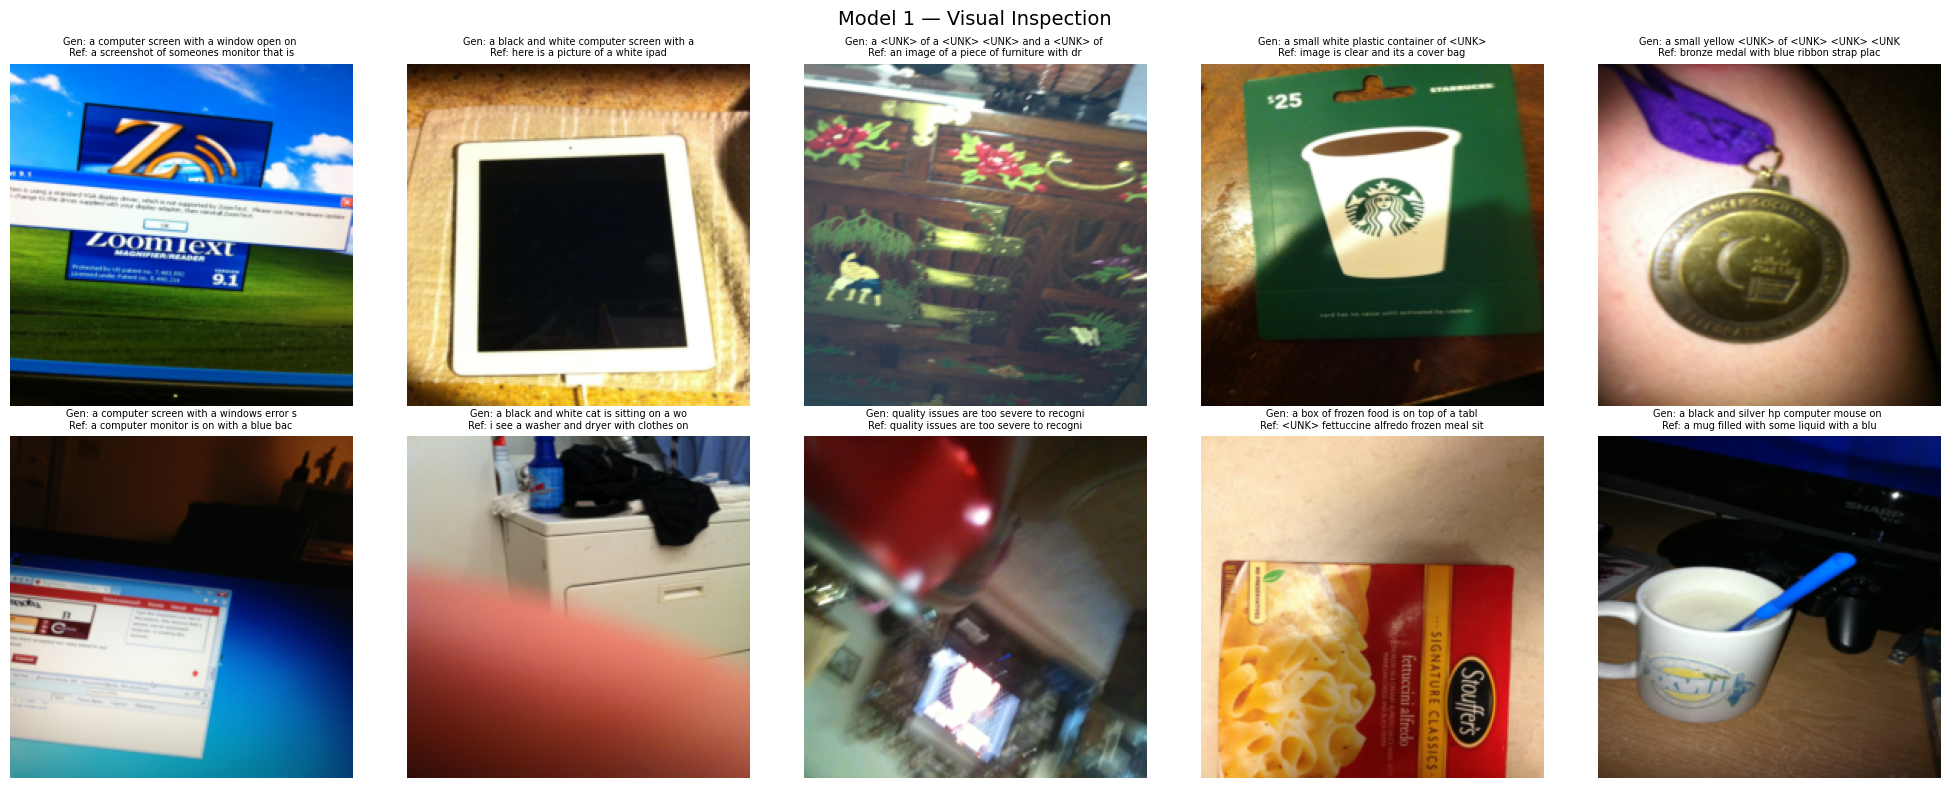

In [14]:
import matplotlib.pyplot as plt
import random

# Load best model
checkpoint = torch.load(MY_CHECKPTS / 'model1_best.pth', map_location=DEVICE)
encoder1.load_state_dict(checkpoint['encoder'])
decoder1.load_state_dict(checkpoint['decoder'])
encoder1.eval()
decoder1.eval()

# Inverse normalisation
inv_normalize = T.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

# Randomly sample 10 images from test set
sample_indices = random.sample(range(len(test_dataset)), 10)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, idx in enumerate(sample_indices):
    img_tensor, cap_tensor = test_dataset[idx]

    # Generate caption
    with torch.no_grad():
        feat = encoder1(img_tensor.unsqueeze(0).to(DEVICE))
        pred_indices = decoder1.generate(feat, max_len=20)
    generated = ' '.join([idx2word.get(j, '<UNK>') for j in pred_indices])

    # Reference caption
    ref = ' '.join([idx2word.get(i.item(), '<UNK>') for i in cap_tensor
                    if i.item() not in [PAD_IDX, SOS_IDX, EOS_IDX]])

    # Display image
    img_show = inv_normalize(img_tensor).permute(1, 2, 0).clamp(0, 1).numpy()
    axes[i].imshow(img_show)
    axes[i].axis('off')
    axes[i].set_title(f'Gen: {generated[:40]}\nRef: {ref[:40]}', fontsize=7)

plt.suptitle('Model 1 — Visual Inspection', fontsize=14)
plt.tight_layout()
plt.savefig(MY_CHECKPTS / 'model1_visual.png')
plt.show()

### Model 1 — Visual inspection

---
# Group Discussion Summary

> *Fill in after the Phase 2 group meeting.*
>
> - What architectures did each teammate try?
> - What worked? What did not, and why?
> - What patterns emerged across experiments?
> - How did the discussion inform your Model 2 design?

### Model 2 — Evaluation & comparison vs. Model 1